# DCGAN desde cero para generar sprites de Pokémon

In [1]:
import os
import requests
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.utils as vutils
from PIL import Image
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


## Hiperparámetros

In [2]:
Z_DIM = 100
IMG_SIZE = 64
IMG_CHANNELS = 3
FEATURES_G = 64
FEATURES_D = 64

BATCH_SIZE = 32
NUM_EPOCHS = 50
LR = 2e-4
BETAS = (0.5, 0.999)

DATA_DIR = "pokemon_sprites"
SEED = 42

torch.manual_seed(SEED)
np.random.seed(SEED)

## Construcción del dataset

Si ya cuenta con el script proporcionado en la plataforma para construir el dataset,
utilícelo en su lugar (debe dejar las 898 imágenes PNG en `DATA_DIR`). A continuación se
incluye una alternativa autocontenida que descarga los sprites directamente desde el
repositorio público de GitHub de PokeAPI (`PokeAPI/sprites`), por si no cuenta con el
script o desea reproducir el dataset desde cero.

In [3]:
def download_pokemon_sprites(data_dir=DATA_DIR, n_pokemon=898):
    """
    Descarga los sprites frontales estandar desde el repositorio de GitHub de PokeAPI.
    Fuente: https://github.com/PokeAPI/sprites
    """
    os.makedirs(data_dir, exist_ok=True)
    base_url = "https://raw.githubusercontent.com/PokeAPI/sprites/master/sprites/pokemon"
    downloaded = 0
    for pid in range(1, n_pokemon + 1):
        out_path = os.path.join(data_dir, f"{pid}.png")
        if os.path.exists(out_path):
            downloaded += 1
            continue
        url = f"{base_url}/{pid}.png"
        try:
            resp = requests.get(url, timeout=10)
            if resp.status_code == 200 and len(resp.content) > 0:
                with open(out_path, "wb") as f:
                    f.write(resp.content)
                downloaded += 1
            else:
                print(f"No se pudo descargar #{pid}: HTTP {resp.status_code}")
        except Exception as e:
            print(f"Error descargando #{pid}: {e}")
        if pid % 100 == 0:
            print(f"Progreso: {pid}/{n_pokemon}")
    print(f"Descarga completa: {downloaded}/{n_pokemon} imagenes en '{data_dir}'")

# Descomente la siguiente linea para descargar el dataset (puede tardar varios minutos)
# download_pokemon_sprites()

Progreso: 100/898


Progreso: 200/898


Progreso: 300/898


Progreso: 400/898


Progreso: 500/898


Progreso: 600/898


Progreso: 700/898


Progreso: 800/898


Descarga completa: 898/898 imagenes en 'pokemon_sprites'


In [4]:
class PokemonSpriteDataset(Dataset):
    def __init__(self, data_dir=DATA_DIR, img_size=IMG_SIZE):
        self.paths = sorted([
            os.path.join(data_dir, f) for f in os.listdir(data_dir)
            if f.lower().endswith(".png")
        ])
        assert len(self.paths) > 0, (
            f"No se encontraron imagenes en '{data_dir}'. "
            "Ejecute download_pokemon_sprites()"
        )
        self.transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.5] * 3, [0.5] * 3),
        ])

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGBA")
        bg = Image.new("RGBA", img.size, (255, 255, 255, 255))
        composited = Image.alpha_composite(bg, img).convert("RGB")
        return self.transform(composited)


dataset = PokemonSpriteDataset()
dataloader = DataLoader(
    dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True, num_workers=0
)
print(f"Dataset cargado: {len(dataset)} imagenes, {len(dataloader)} batches por epoca")

Dataset cargado: 898 imagenes, 28 batches por epoca


## Task 1.1 - Generador y Discriminador

In [5]:
class Generator(nn.Module):
    def __init__(self, z_dim=Z_DIM, img_channels=IMG_CHANNELS, features_g=FEATURES_G):
        super().__init__()
        self.net = nn.Sequential(
            # z: (batch, z_dim, 1, 1) -> (batch, features_g*8, 4, 4)
            nn.ConvTranspose2d(z_dim, features_g * 8, kernel_size=4, stride=1, padding=0, bias=False),
            nn.BatchNorm2d(features_g * 8),
            nn.ReLU(True),
            # -> (batch, features_g*4, 8, 8)
            nn.ConvTranspose2d(features_g * 8, features_g * 4, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(features_g * 4),
            nn.ReLU(True),
            # -> (batch, features_g*2, 16, 16)
            nn.ConvTranspose2d(features_g * 4, features_g * 2, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(features_g * 2),
            nn.ReLU(True),
            # -> (batch, features_g, 32, 32)
            nn.ConvTranspose2d(features_g * 2, features_g, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(features_g),
            nn.ReLU(True),
            # -> (batch, img_channels, 64, 64)
            nn.ConvTranspose2d(features_g, img_channels, kernel_size=4, stride=2, padding=1, bias=False),
            nn.Tanh(),
        )

    def forward(self, z):
        return self.net(z)


class Discriminator(nn.Module):
    def __init__(self, img_channels=IMG_CHANNELS, features_d=FEATURES_D):
        super().__init__()
        self.net = nn.Sequential(
            # (batch, 3, 64, 64) -> (batch, features_d, 32, 32)
            nn.Conv2d(img_channels, features_d, kernel_size=4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # -> (batch, features_d*2, 16, 16)
            nn.Conv2d(features_d, features_d * 2, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(features_d * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # -> (batch, features_d*4, 8, 8)
            nn.Conv2d(features_d * 2, features_d * 4, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(features_d * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # -> (batch, features_d*8, 4, 4)
            nn.Conv2d(features_d * 4, features_d * 8, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(features_d * 8),
            nn.LeakyReLU(0.2, inplace=True),
            # -> (batch, 1, 1, 1)
            nn.Conv2d(features_d * 8, 1, kernel_size=4, stride=1, padding=0, bias=False),
            nn.Sigmoid(),
        )

    def forward(self, x):
        out = self.net(x)
        return out.view(-1)

In [6]:
def weights_init(m): #Función para inicializar los pesos de la red, recibe como parámetro el módulo actual 
    classname = m.__class__.__name__
    if classname.find("Conv") != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find("BatchNorm") != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

In [7]:
G = Generator().to(device)
D = Discriminator().to(device)
G.apply(weights_init)
D.apply(weights_init)

# Verificacion de formas exactas
z = torch.randn(4, Z_DIM, 1, 1, device=device)
assert G(z).shape == (4, 3, 64, 64), "Forma del generador incorrecta"
assert D(torch.randn(4, 3, 64, 64, device=device)).shape == (4,), "Forma del discriminador incorrecta"
print("Formas verificadas correctamente: G -> (4, 3, 64, 64), D -> (4,)")

Formas verificadas correctamente: G -> (4, 3, 64, 64), D -> (4,)


In [8]:
print(G)

Generator(
  (net): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=

In [9]:
print(D)

Discriminator(
  (net): Sequential(
    (0): Conv2d(3, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (9): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
    (11): Conv2d(512, 1, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (12): Sigmoid()
  )


## Task 1.2 - Entrenamiento alternado

In [10]:
criterion = nn.BCELoss()
opt_G = optim.Adam(G.parameters(), lr=LR, betas=BETAS)
opt_D = optim.Adam(D.parameters(), lr=LR, betas=BETAS)

fixed_noise = torch.randn(16, Z_DIM, 1, 1, device=device)

REAL_LABEL = 1.0
FAKE_LABEL = 0.0

losses_G = []
losses_D = []
img_grids_per_epoch = []  # una grilla (tensor) por epoca, generada con fixed_noise

In [11]:
for epoch in range(NUM_EPOCHS):
    epoch_loss_G = 0.0
    epoch_loss_D = 0.0
    num_batches = 0

    for real_imgs in dataloader:
        real_imgs = real_imgs.to(device)
        batch_size = real_imgs.size(0)

        # Paso del Discriminador
        D.zero_grad()

        labels_real = torch.full((batch_size,), REAL_LABEL, dtype=torch.float, device=device)
        output_real = D(real_imgs)
        loss_D_real = criterion(output_real, labels_real)

        noise = torch.randn(batch_size, Z_DIM, 1, 1, device=device)
        fake_imgs = G(noise)
        labels_fake = torch.full((batch_size,), FAKE_LABEL, dtype=torch.float, device=device)
        output_fake = D(fake_imgs.detach())  # detach: no propagar gradiente hacia G
        loss_D_fake = criterion(output_fake, labels_fake)

        loss_D = loss_D_real + loss_D_fake
        loss_D.backward()
        opt_D.step()

        # Paso del Generador
        G.zero_grad()

        noise_g = torch.randn(batch_size, Z_DIM, 1, 1, device=device)
        fake_imgs_for_G = G(noise_g)
        output_for_G = D(fake_imgs_for_G)
        # Truco de Goodfellow: G quiere que D clasifique sus salidas como reales (etiqueta 1)
        loss_G = criterion(output_for_G, labels_real)
        loss_G.backward()
        opt_G.step()

        epoch_loss_D += loss_D.item()
        epoch_loss_G += loss_G.item()
        num_batches += 1

    avg_loss_D = epoch_loss_D / num_batches
    avg_loss_G = epoch_loss_G / num_batches
    losses_D.append(avg_loss_D)
    losses_G.append(avg_loss_G)

    # Grilla de 16 imagenes con ruido fijo, para visualizar la evolucion
    G.eval()
    with torch.no_grad():
        fake_fixed = G(fixed_noise).detach().cpu()
        grid = vutils.make_grid(fake_fixed, nrow=4, normalize=True, padding=2)
        img_grids_per_epoch.append(grid)
    G.train()

    print(f"Epoca [{epoch+1}/{NUM_EPOCHS}]  loss_D: {avg_loss_D:.4f}  loss_G: {avg_loss_G:.4f}")

Epoca [1/50]  loss_D: 0.2938  loss_G: 9.2833


Epoca [2/50]  loss_D: 0.7124  loss_G: 18.2295


Epoca [3/50]  loss_D: 1.7264  loss_G: 13.3806


Epoca [4/50]  loss_D: 0.9337  loss_G: 6.7041


Epoca [5/50]  loss_D: 0.8143  loss_G: 6.6736


...

Epoca [46/50]  loss_D: 0.6432  loss_G: 4.5589


Epoca [47/50]  loss_D: 0.4224  loss_G: 3.9282


Epoca [48/50]  loss_D: 0.3353  loss_G: 4.1935


Epoca [49/50]  loss_D: 0.3111  loss_G: 3.7216


Epoca [50/50]  loss_D: 0.7549  loss_G: 4.4090


## Task 1.3 - Visualizaciones

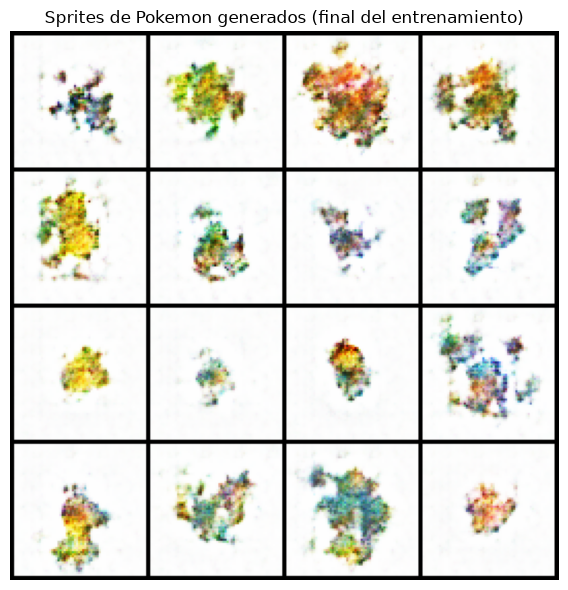

In [12]:
G.eval()
with torch.no_grad():
    final_fake = G(fixed_noise).detach().cpu()

# Desnormalizar de [-1, 1] (salida de Tanh) a [0, 255]
final_fake_denorm = (final_fake + 1) / 2 * 255
final_fake_denorm = final_fake_denorm.clamp(0, 255).to(torch.uint8)

# make_grid espera floats; reescalamos a [0,1] solo para el despliegue
grid_final = vutils.make_grid(final_fake_denorm.float() / 255.0, nrow=4, padding=2)

plt.figure(figsize=(6, 6))
plt.axis("off")
plt.title("Sprites de Pokemon generados (final del entrenamiento)")
plt.imshow(np.transpose(grid_final.numpy(), (1, 2, 0)))
plt.tight_layout()
plt.show()

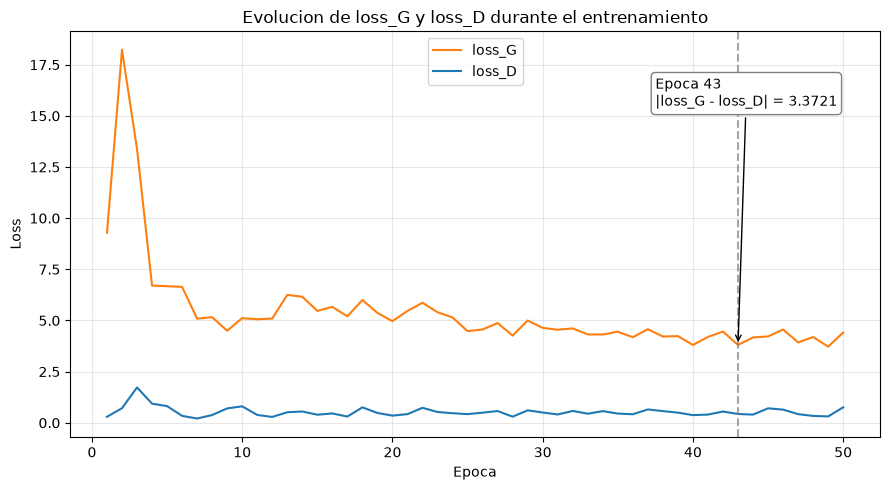

Punto de mayor cercania entre las perdidas: epoca 43 (loss_G=3.8030, loss_D=0.4309)


In [13]:
losses_G_arr = np.array(losses_G)
losses_D_arr = np.array(losses_D)
diff = np.abs(losses_G_arr - losses_D_arr)
closest_epoch = int(np.argmin(diff))  # indice 0-based

plt.figure(figsize=(9, 5))
plt.plot(range(1, NUM_EPOCHS + 1), losses_G_arr, label="loss_G", color="tab:orange")
plt.plot(range(1, NUM_EPOCHS + 1), losses_D_arr, label="loss_D", color="tab:blue")
plt.axvline(closest_epoch + 1, color="gray", linestyle="--", alpha=0.7)

y_max = max(losses_G_arr.max(), losses_D_arr.max())
plt.annotate(
    f"Epoca {closest_epoch + 1}\n|loss_G - loss_D| = {diff[closest_epoch]:.4f}",
    xy=(closest_epoch + 1, losses_G_arr[closest_epoch]),
    xytext=(min(closest_epoch + 1 + NUM_EPOCHS * 0.08, NUM_EPOCHS * 0.75), y_max * 0.85),
    arrowprops=dict(arrowstyle="->", color="black"),
    fontsize=10,
    bbox=dict(boxstyle="round", fc="white", ec="gray"),
)

plt.xlabel("Epoca")
plt.ylabel("Loss")
plt.title("Evolucion de loss_G y loss_D durante el entrenamiento")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Punto de mayor cercania entre las perdidas: epoca {closest_epoch + 1} "
      f"(loss_G={losses_G_arr[closest_epoch]:.4f}, loss_D={losses_D_arr[closest_epoch]:.4f})")

# Task 2 - Dinámica adversarial y divergencia de Jensen-Shannon

<!-- madagascar -->

Los experimentos de esta sección usan instancias independientes de `Generator` y `Discriminator`; por lo tanto, no modifican los modelos `G` y `D` ni los historiales de Task 1.

## Task 2.1 - Cinco actualizaciones de D por cada actualización de G

Se entrenará durante 20 épocas con una razón exacta $n_D:n_G=5:1$. Se registran las pérdidas medias por época y la norma $\ell_2$ global del gradiente del generador.

In [14]:
NUM_EPOCHS_COLLAPSE = 20
D_STEPS_PER_G = 5

# Instancias nuevas: el experimento no sobrescribe G, D, opt_G ni opt_D de Task 1.
torch.manual_seed(SEED + 1)
G_collapse = Generator().to(device)
D_collapse = Discriminator().to(device)
G_collapse.apply(weights_init)
D_collapse.apply(weights_init)

criterion_collapse = nn.BCELoss()
opt_G_collapse = optim.Adam(G_collapse.parameters(), lr=LR, betas=BETAS)
opt_D_collapse = optim.Adam(D_collapse.parameters(), lr=LR, betas=BETAS)
fixed_noise_collapse = torch.randn(16, Z_DIM, 1, 1, device=device)
losses_D_collapse, losses_G_collapse = [], []
grad_norms_G_collapse, img_grids_collapse = [], []
updates_D_collapse = updates_G_collapse = 0

In [15]:
for epoch in range(NUM_EPOCHS_COLLAPSE):
    epoch_loss_D = epoch_loss_G = epoch_grad_norm_G = 0.0
    num_updates_G_epoch = 0
    G_collapse.train()
    D_collapse.train()

    for real_imgs in dataloader:
        real_imgs = real_imgs.to(device)
        batch_size = real_imgs.size(0)
        labels_real = torch.full((batch_size,), REAL_LABEL, device=device)
        labels_fake = torch.full((batch_size,), FAKE_LABEL, device=device)

        # Cinco pasos completos de D antes de cada paso de G.
        G_collapse.eval()  # evita actualizar el estado de BatchNorm de G
        D_collapse.train()
        for _ in range(D_STEPS_PER_G):
            opt_D_collapse.zero_grad(set_to_none=True)
            loss_D_real = criterion_collapse(D_collapse(real_imgs), labels_real)
            noise_d = torch.randn(batch_size, Z_DIM, 1, 1, device=device)
            with torch.no_grad():
                fake_imgs_d = G_collapse(noise_d)
            loss_D_fake = criterion_collapse(D_collapse(fake_imgs_d), labels_fake)
            loss_D_collapse = loss_D_real + loss_D_fake
            loss_D_collapse.backward()
            opt_D_collapse.step()
            epoch_loss_D += loss_D_collapse.item()
            updates_D_collapse += 1

        # Un paso de G con la pérdida no saturante BCE(target=1).
        G_collapse.train()
        D_collapse.eval()  # evita actualizar el estado de BatchNorm de D
        for parameter in D_collapse.parameters():
            parameter.requires_grad_(False)
        opt_G_collapse.zero_grad(set_to_none=True)
        noise_g = torch.randn(batch_size, Z_DIM, 1, 1, device=device)
        loss_G_collapse = criterion_collapse(D_collapse(G_collapse(noise_g)), labels_real)
        loss_G_collapse.backward()
        grad_norm_G = sum(
            parameter.grad.detach().norm(2).item() ** 2
            for parameter in G_collapse.parameters() if parameter.grad is not None
        ) ** 0.5
        opt_G_collapse.step()
        for parameter in D_collapse.parameters():
            parameter.requires_grad_(True)

        epoch_loss_G += loss_G_collapse.item()
        epoch_grad_norm_G += grad_norm_G
        updates_G_collapse += 1
        num_updates_G_epoch += 1

    avg_loss_D_collapse = epoch_loss_D / (D_STEPS_PER_G * num_updates_G_epoch)
    avg_loss_G_collapse = epoch_loss_G / num_updates_G_epoch
    avg_grad_norm_G_collapse = epoch_grad_norm_G / num_updates_G_epoch
    losses_D_collapse.append(avg_loss_D_collapse)
    losses_G_collapse.append(avg_loss_G_collapse)
    grad_norms_G_collapse.append(avg_grad_norm_G_collapse)

    G_collapse.eval()
    with torch.no_grad():
        fake_fixed_epoch = G_collapse(fixed_noise_collapse).cpu()
        img_grids_collapse.append(
            vutils.make_grid(((fake_fixed_epoch + 1) / 2).clamp(0, 1), nrow=4, padding=2)
        )
    print(f"Epoca [{epoch + 1}/{NUM_EPOCHS_COLLAPSE}]  loss_D: {avg_loss_D_collapse:.4f}  "
          f"loss_G: {avg_loss_G_collapse:.4f}  ||grad G||_2: {avg_grad_norm_G_collapse:.4e}")

assert updates_D_collapse == D_STEPS_PER_G * updates_G_collapse
print(f"Razon verificada: {updates_D_collapse} actualizaciones de D / "
      f"{updates_G_collapse} de G = {D_STEPS_PER_G}:1")

Epoca [1/20]  loss_D: 0.0101  loss_G: 0.2104  ||grad G||_2: 8.7550e-01


Epoca [2/20]  loss_D: 0.0000  loss_G: 0.0012  ||grad G||_2: 7.4428e-02


Epoca [3/20]  loss_D: 0.0000  loss_G: 0.0007  ||grad G||_2: 3.5045e-02


Epoca [4/20]  loss_D: 0.0000  loss_G: 0.0003  ||grad G||_2: 1.6909e-02


Epoca [5/20]  loss_D: 0.0000  loss_G: 0.0002  ||grad G||_2: 9.4424e-03


...

Epoca [16/20]  loss_D: 0.0000  loss_G: 0.0000  ||grad G||_2: 1.0965e-03


Epoca [17/20]  loss_D: 0.0000  loss_G: 0.0000  ||grad G||_2: 1.0609e-03


Epoca [18/20]  loss_D: 0.0000  loss_G: 0.0000  ||grad G||_2: 9.3001e-04


Epoca [19/20]  loss_D: 0.0000  loss_G: 0.0000  ||grad G||_2: 9.0111e-04


Epoca [20/20]  loss_D: 0.0000  loss_G: 0.0000  ||grad G||_2: 7.8602e-04
Razon verificada: 2800 actualizaciones de D / 560 de G = 5:1


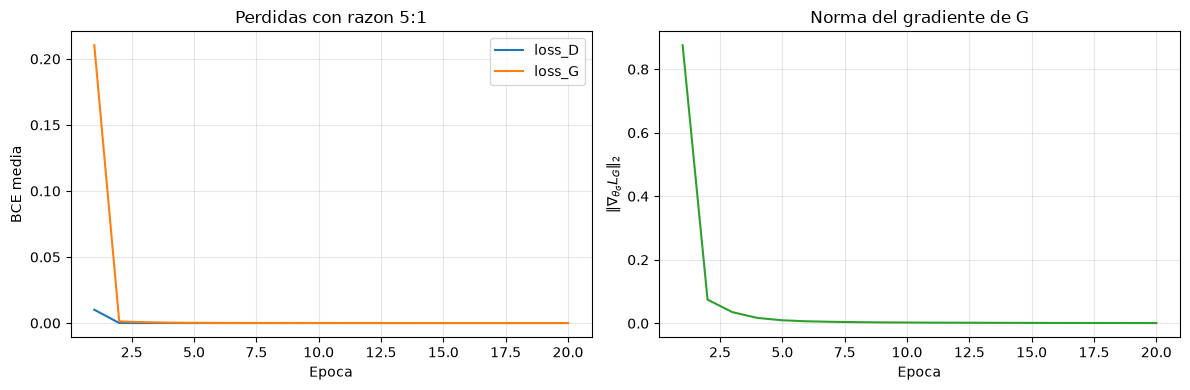

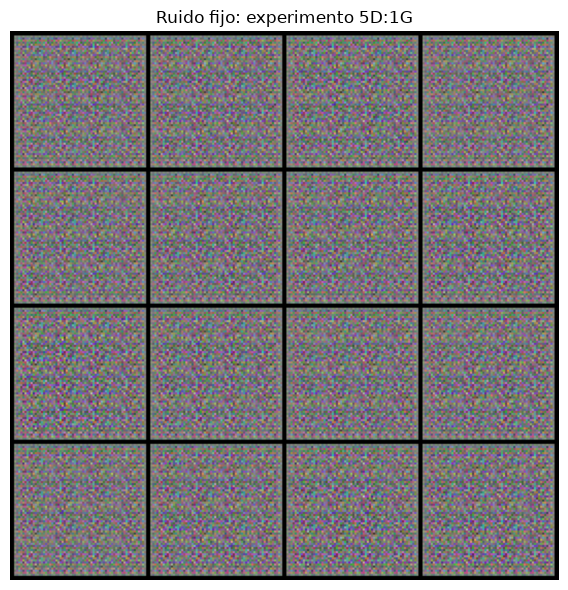

Diversidad L1 media entre pares (5D:1G): 0.043811
Diversidad L1 media entre pares (Task 1): 0.077568
Razon de diversidad 5D:1G / Task 1: 0.564812
Desviacion estandar media por pixel/canal (5D:1G): 0.036958


In [16]:
epochs_collapse = np.arange(1, NUM_EPOCHS_COLLAPSE + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(epochs_collapse, losses_D_collapse, label="loss_D")
axes[0].plot(epochs_collapse, losses_G_collapse, label="loss_G")
axes[0].set(title="Perdidas con razon 5:1", xlabel="Epoca", ylabel="BCE media")
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(epochs_collapse, grad_norms_G_collapse, color="tab:green")
axes[1].set(title="Norma del gradiente de G", xlabel="Epoca",
            ylabel=r"$\|\nabla_{\theta_G} L_G\|_2$")
axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

G_collapse.eval()
with torch.no_grad():
    generated_fixed = G_collapse(fixed_noise_collapse).cpu()
generated_fixed_01 = ((generated_fixed + 1) / 2).clamp(0, 1)
grid_collapse = vutils.make_grid(generated_fixed_01, nrow=4, padding=2)
flat_generated = generated_fixed_01.flatten(start_dim=1)
diversity_l1_collapse = (torch.pdist(flat_generated, p=1) / flat_generated.shape[1]).mean().item()
pixel_std_collapse = generated_fixed_01.std(dim=0, unbiased=False).mean().item()

# Referencia cuantitativa con el G entrenado en Task 1 y el mismo ruido.
task1_was_training = G.training
G.eval()
with torch.no_grad():
    generated_task1_01 = ((G(fixed_noise_collapse).cpu() + 1) / 2).clamp(0, 1)
if task1_was_training:
    G.train()
flat_task1 = generated_task1_01.flatten(start_dim=1)
diversity_l1_task1 = (torch.pdist(flat_task1, p=1) / flat_task1.shape[1]).mean().item()
diversity_ratio = diversity_l1_collapse / max(diversity_l1_task1, np.finfo(float).eps)

plt.figure(figsize=(6, 6))
plt.axis("off"); plt.title("Ruido fijo: experimento 5D:1G")
plt.imshow(np.transpose(grid_collapse.numpy(), (1, 2, 0)))
plt.tight_layout(); plt.show()
print(f"Diversidad L1 media entre pares (5D:1G): {diversity_l1_collapse:.6f}")
print(f"Diversidad L1 media entre pares (Task 1): {diversity_l1_task1:.6f}")
print(f"Razon de diversidad 5D:1G / Task 1: {diversity_ratio:.6f}")
print(f"Desviacion estandar media por pixel/canal (5D:1G): {pixel_std_collapse:.6f}")

### Respuestas Task 2.1

**a) Por qué cinco actualizaciones de $D$ por cada una de $G$ pueden inducir colapso modal.** Esta asimetría permite que $D$ se aproxime rápidamente a una separación casi perfecta mientras $G$ cambia poco. Sea $D(x)=\sigma(a_D(x))$. Para la pérdida minimax saturante, $L_G^{\mathrm{sat}}=\mathbb{E}_z[\log(1-D(G(z)))]$, se cumple $\partial L_G^{\mathrm{sat}}/\partial a_D=-D(G(z))\to0$ cuando $D(G(z))\approx0$. En ese caso, la señal que llega a $G$ desaparece y este no obtiene una dirección para abandonar el modo en el que quedó concentrado. Sin embargo, el notebook **no usa esa pérdida**: usa la no saturante $L_G^{\mathrm{NS}}=-\mathbb{E}_z[\log D(G(z))]$ mediante BCE con objetivo 1, para la cual $\partial L_G^{\mathrm{NS}}/\partial a_D=D(G(z))-1\to-1$. Por tanto, $D(G(z))\approx0$ por sí solo **no demuestra** que $\nabla_{\theta_G}L_G$ sea nulo bajo la pérdida implementada.

Aun con la pérdida no saturante, $\nabla_{\theta_G}L_G=\mathbb{E}_z[J_G(z)^\top J_{a_D}(G(z))^\top(D(G(z))-1)]$ puede ser pequeño si un discriminador sobreentrenado desarrolla regiones localmente planas o saturadas respecto de su entrada, es decir, si $J_{a_D}(G(z))$ es pequeño. Además, cuando muchas entradas $z$ ya producen muestras casi iguales, reciben gradientes similares y se desplazan hacia el mismo modo; como no hay muestras en los modos ausentes, esos gradientes no aportan una dirección para recuperarlos. Así, $G$ puede quedar atrapado sin una señal útil de recuperación, aunque el factor de salida no saturante no desaparezca. La norma almacenada en `grad_norms_G_collapse` es la que debe comprobar experimentalmente si el gradiente realmente se deteriora; no corresponde inferirlo únicamente de $D(G(z))\approx0$.

**b) Valor de $D^*(x)$ sobre una imagen repetida.** El discriminador óptimo para un generador fijo es $D^*(x)=p_{\mathrm{data}}(x)/(p_{\mathrm{data}}(x)+p_G(x))$. En un sprite que $G$ repite, $p_G$ concentra mucha masa y normalmente domina a $p_{\mathrm{data}}$, por lo que $D^*(x)\approx0$. Si ese sprite no pertenece al soporte de los datos y $p_{\mathrm{data}}(x)=0$, entonces $D^*(x)=0$ exactamente. El valor $1/2$ solo corresponde al equilibrio local $p_G(x)=p_{\mathrm{data}}(x)$, no al colapso modal descrito.

**c) Modificación concreta del loop: instance noise con decaimiento.** Se puede añadir ruido gaussiano de igual distribución a imágenes reales y falsas justo antes de cada evaluación de $D$, incluida la evaluación usada para actualizar $G$, con una desviación $\sigma$ que disminuya por época:

```python
sigma = sigma_0 * max(0.0, 1.0 - epoch / decay_epochs)
real_in = real_imgs + sigma * torch.randn_like(real_imgs)
fake_in = fake_imgs + sigma * torch.randn_like(fake_imgs)
loss_D = BCE(D(real_in), real_targets) + BCE(D(fake_in.detach()), fake_targets)
loss_G = BCE(D(fake_in), real_targets)
```

El ruido convoluciona y suaviza los soportes efectivos de $p_{\mathrm{data}}$ y $p_G$, crea solapamiento cuando al inicio serían fácilmente separables y dificulta que $D$ alcance una frontera perfecta demasiado pronto. Esto favorece que $J_{a_D}(G(z))$ conserve gradientes respecto de la entrada más informativos para actualizar $G$; el decaimiento retira gradualmente la regularización a medida que mejora el generador. Es una mitigación implementable, no una garantía de que el colapso modal no ocurra.

**Resultados experimentales e interpretación.** En la época 1, `loss_D=0.0101`, `loss_G=0.2104` y la norma media del gradiente de $G$ fue $8.7550\times10^{-1}$; en la época 20, los valores impresos fueron `loss_D=0.0000`, `loss_G=0.0000` y $7.8602\times10^{-4}$, respectivamente. La diversidad L1 media fue `0.043811` para 5D:1G y `0.077568` para Task 1, con una razón `0.564812`; la desviación estándar media por píxel/canal fue `0.036958`.

La grilla final muestra 16 texturas ruidosas casi indistinguibles, sin formas reconocibles de Pokémon y con variaciones locales pequeñas. La inspección visual y la reducción de diversidad a aproximadamente el 56.5 % de la referencia de Task 1 evidencian baja diversidad y son consistentes con un colapso degenerativo en este experimento. No obstante, el resultado también revela que el generador 5D:1G no aprendió sprites significativos; por ello, no debe interpretarse como concentración exitosa en un modo semántico reconocible. La caída de la norma del gradiente en más de tres órdenes de magnitud aporta evidencia experimental de deterioro de la señal, sin confundir este comportamiento con la saturación matemática de la pérdida minimax: el loop utilizó la pérdida no saturante BCE con objetivo 1.


## Task 2.2 - Estimación de la divergencia de Jensen-Shannon

En Task 1, `loss_D` es la suma de las BCE para datos reales y falsos. Por tanto,

$$V(D,G)=\mathbb{E}_{x\sim p_{\mathrm{data}}}\log D(x)+\mathbb{E}_{z}\log(1-D(G(z)))=-\,loss_D.$$

Si $D=D^*$ es óptimo para un $G$ fijo, $V(D^*,G)=-\log 4+2\,\operatorname{JSD}(p_{\mathrm{data}}\|p_G)$ y $\widehat{\operatorname{JSD}}=(-loss_D+\log4)/2$. `loss_G` no se suma: en Task 1 es la pérdida no saturante $-\mathbb{E}_z\log D(G(z))$, una función alternativa para actualizar $G$, y no pertenece a la identidad de $V(D,G)$.

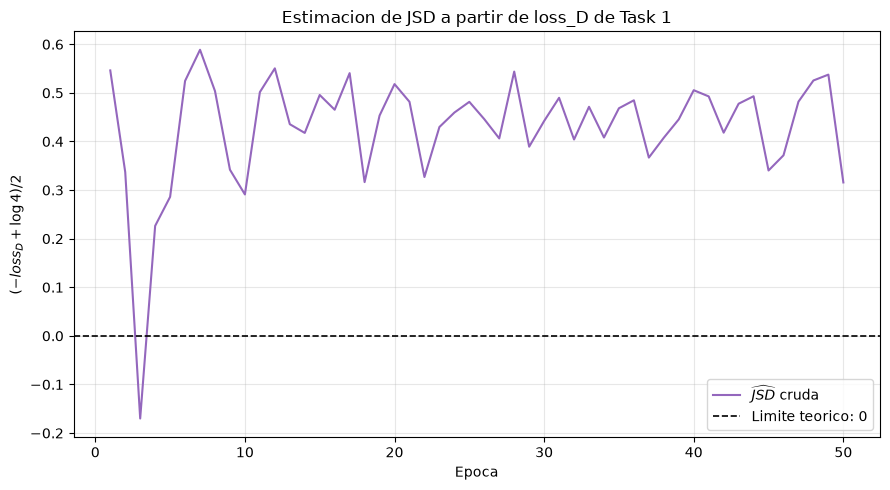

Epocas con estimacion cruda negativa: 1/50
Estimacion cruda inicial: 0.546225
Estimacion cruda final: 0.315710
losses_G se valida como historial paralelo, pero no interviene en la identidad de V(D,G).


In [17]:
losses_D_task1 = np.asarray(losses_D, dtype=float)
losses_G_task1 = np.asarray(losses_G, dtype=float)
if losses_D_task1.size == 0:
    raise RuntimeError("Ejecute primero el entrenamiento de Task 1 para obtener losses_D.")
if losses_D_task1.shape != losses_G_task1.shape:
    raise ValueError("Los historiales losses_D y losses_G de Task 1 deben tener la misma longitud.")

value_hat_task1 = -losses_D_task1
jsd_hat_raw = (value_hat_task1 + np.log(4.0)) / 2.0
epochs_task1 = np.arange(1, losses_D_task1.size + 1)
plt.figure(figsize=(9, 5))
plt.plot(epochs_task1, jsd_hat_raw, label=r"$\widehat{JSD}$ cruda", color="tab:purple")
plt.axhline(0, color="black", linestyle="--", linewidth=1.2, label="Limite teorico: 0")
plt.xlabel("Epoca"); plt.ylabel(r"$(-loss_D + \log 4)/2$")
plt.title("Estimacion de JSD a partir de loss_D de Task 1")
plt.grid(alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()

negative_count = int(np.count_nonzero(jsd_hat_raw < 0))
print(f"Epocas con estimacion cruda negativa: {negative_count}/{jsd_hat_raw.size}")
print(f"Estimacion cruda inicial: {jsd_hat_raw[0]:.6f}")
print(f"Estimacion cruda final: {jsd_hat_raw[-1]:.6f}")
print("losses_G se valida como historial paralelo, pero no interviene en la identidad de V(D,G).")

### Respuestas Task 2.2

**a) Sesgo por un discriminador subóptimo.** Para un generador fijo, $D^*$ maximiza la función de valor, de modo que $V(D,G)\leq V(D^*,G)$. Al aplicar la transformación afín, $\widehat{\operatorname{JSD}}(D,G)\leq\operatorname{JSD}(p_{\mathrm{data}}\|p_G)$. Por ello, el discriminador entrenado pero no óptimo **subestima** la JSD teórica. Pueden aparecer estimaciones crudas negativas porque $V(D,G)$ puede ser menor que $-\log4$; se muestran sin recorte y no constituyen una JSD válida.

**b) Convergencia.** En el equilibrio ideal $p_G=p_{\mathrm{data}}$, se cumple $D^*(x)=1/2$, $V(D^*,G)=-\log4$ y $\operatorname{JSD}=0$. En la ejecución de Task 1, la estimación cruda pasó de `0.546225` en la primera época a `0.315710` en la última; fue negativa en `1/50` épocas. El valor final es menor que el inicial, pero permanece lejos de cero y la trayectoria no demuestra convergencia al equilibrio. La estimación negativa aislada no representa una divergencia real negativa: refleja que el discriminador entrenado no es el óptimo $D^*$ requerido por la identidad teórica.


## Task 3 - Investigacion: soluciones al colapso modal

**Opcion elegida:** Opcion C, colapso modal y falta de diversidad en las muestras generadas.

**Paper objetivo:** *Unrolled Generative Adversarial Networks* (Luke Metz, Ben Poole, David Pfau y Jascha Sohl-Dickstein), publicado en ICLR 2017.


### Respuestas Task 3

**a) Problema identificado y su formulación matemática.** El paper elegido es *Unrolled Generative Adversarial Networks* (Metz, Poole, Pfau y Sohl-Dickstein, ICLR 2017), que aborda el colapso modal descrito en la Opción C. Los autores señalan que la garantía teórica de Goodfellow et al. (2014), según la cual el discriminador óptimo $D^*(x)=p_{\mathrm{data}}(x)/(p_{\mathrm{data}}(x)+p_G(x))$ produce un gradiente bien comportado para $G$, solo es válida cuando $D$ alcanza su óptimo en cada paso. En la práctica, el entrenamiento alternado actualiza $\theta_D$ y $\theta_G$ con la misma función inmediata $f(\theta_G,\theta_D)$, sin que $\theta_D$ llegue a $\theta_D^*(\theta_G)$ antes de cada paso de $G$. Formalmente, la actualización estándar es $\theta_D\leftarrow\theta_D+\eta\,df(\theta_G,\theta_D)/d\theta_D$ y $\theta_G\leftarrow\theta_G-\eta\,df(\theta_G,\theta_D)/d\theta_G$. Como $G$ solo "ve" el estado actual de $D$ y no cómo reaccionará éste, el generador tiende a mover toda su masa de probabilidad hacia el punto que en ese instante engaña a $D$, generando el conocido ciclo en que $D$ persigue ese punto y $G$ salta a otro, sin cubrir nunca la distribución completa.

**b) Modificación propuesta.** El paper introduce una función objetivo sustituta (surrogate) para $G$, construida "desenrollando" $K$ pasos hipotéticos de actualización de $D$: partiendo de $\theta_D^0=\theta_D$, se calcula $\theta_D^{k+1}=\theta_D^k+\eta^k\,df(\theta_G,\theta_D^k)/d\theta_D^k$ hasta obtener $\theta_D^K(\theta_G,\theta_D)$. Con ese discriminador proyectado se define $f_K(\theta_G,\theta_D)=f(\theta_G,\theta_D^K(\theta_G,\theta_D))$, y el generador se actualiza con $\theta_G\leftarrow\theta_G-\eta\,df_K(\theta_G,\theta_D)/d\theta_G$, mientras que $D$ sigue usando la pérdida real, no la sustituta. Al derivar $f_K$ respecto de $\theta_G$ aparece, además del término directo, uno adicional que captura cómo cambiaría $D$ ante un movimiento de $G$, de modo que el generador recibe información anticipada sobre la reacción del discriminador. Con $K=0$ se recupera el entrenamiento GAN estándar, y a medida que $K$ crece la actualización se acerca a entrenar contra el discriminador óptimo real.

**c) Conexión con la Parte 2.** El experimento de Task 2.1, con razón $5D:1G$, reproduce en la práctica el problema que motiva el paper: al dar a $D$ muchas más actualizaciones que a $G$, el discriminador se acerca rápidamente a una separación casi perfecta y localmente óptima, pero $G$ solo ve ese estado congelado, sin ninguna anticipación de cómo $D$ se movería después. Los valores registrados lo confirman: la norma del gradiente de $G$ cayó de $8.7550\times10^{-1}$ en la época 1 a $7.8602\times10^{-4}$ en la época 20, una reducción de más de tres órdenes de magnitud, mientras `loss_D` y `loss_G` se acercaron a cero, señal de que $D$ dejó de aportar una dirección útil. La diversidad L1 de las muestras cayó a aproximadamente el 56.5 % de la referencia de Task 1, consistente con concentración en pocos modos. Con el mecanismo de unrolling, la actualización de $G$ habría incluido el término adicional que anticipa la reacción de $D$ ante concentrar masa en un solo punto; esa señal empujaría a $G$ a repartir su salida hacia regiones que $D$ todavía no penaliza con fuerza, lo que en principio evitaría que la norma del gradiente colapsara tan rápido y mantendría una diversidad más cercana a la observada en Task 1.